### 1. **Introduction to Spark SQL**

Spark SQL is a component of Apache Spark that allows for querying structured data using SQL queries. It integrates relational data processing with Spark’s functional programming API, providing a unified interface for data manipulation. It supports a wide range of data formats and sources, including JSON, Parquet, Avro, and JDBC.

> https://www.databricks.com/glossary/what-is-spark-sql

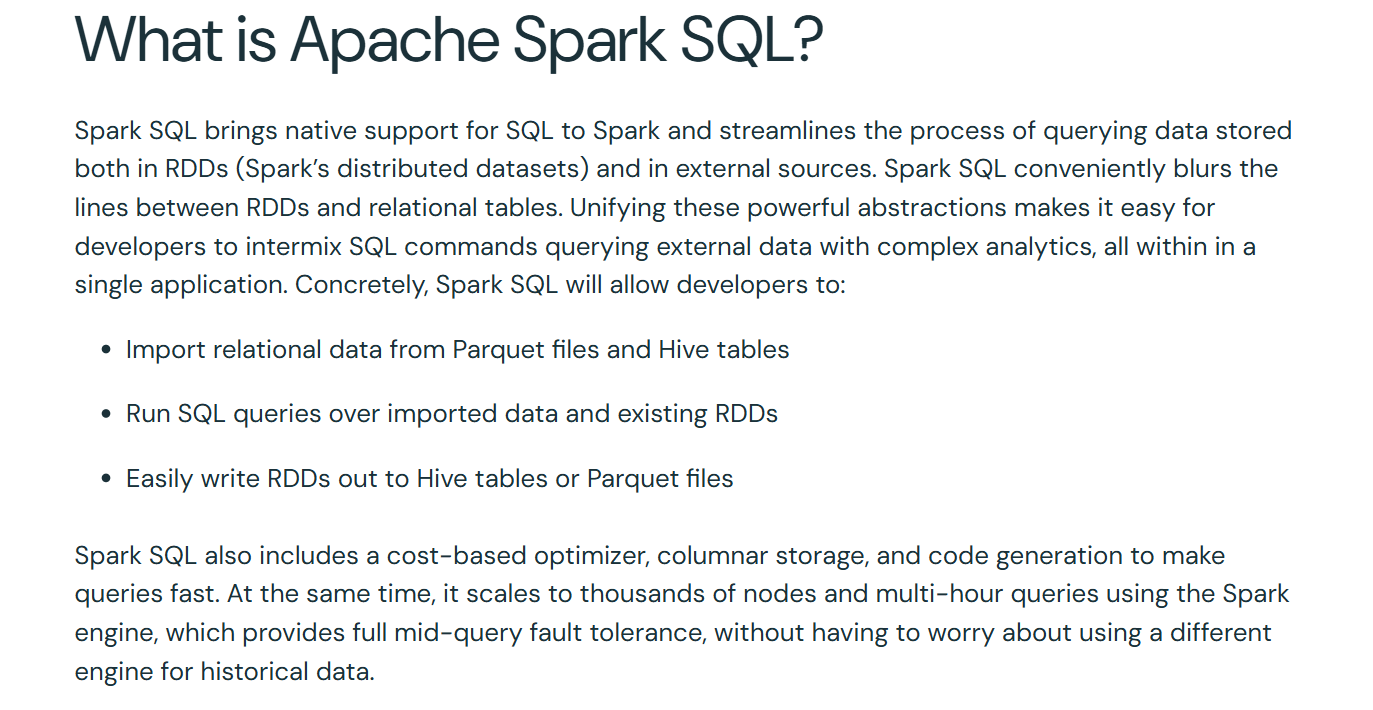

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("DirectSQLTesting") \
    .getOrCreate()



In [7]:

result = spark.sql(
    """
    SELECT * FROM csv.`/content/disney_plus_shows.csv` LIMIT 10;
    """)

result.show()

+----------+--------------------+--------------------+--------------------+-----+-----+-----------+-----------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------+--------------------+--------------------+-----------+----------+
|       _c0|                 _c1|                 _c2|                 _c3|  _c4|  _c5|        _c6|              _c7|              _c8|                 _c9|                _c10|                _c11|                _c12|                _c13|           _c14|                _c15|                _c16|       _c17|      _c18|
+----------+--------------------+--------------------+--------------------+-----+-----+-----------+-----------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------+--------------------+--------------------+-----------+----------+
|   imdb_id|               title| 

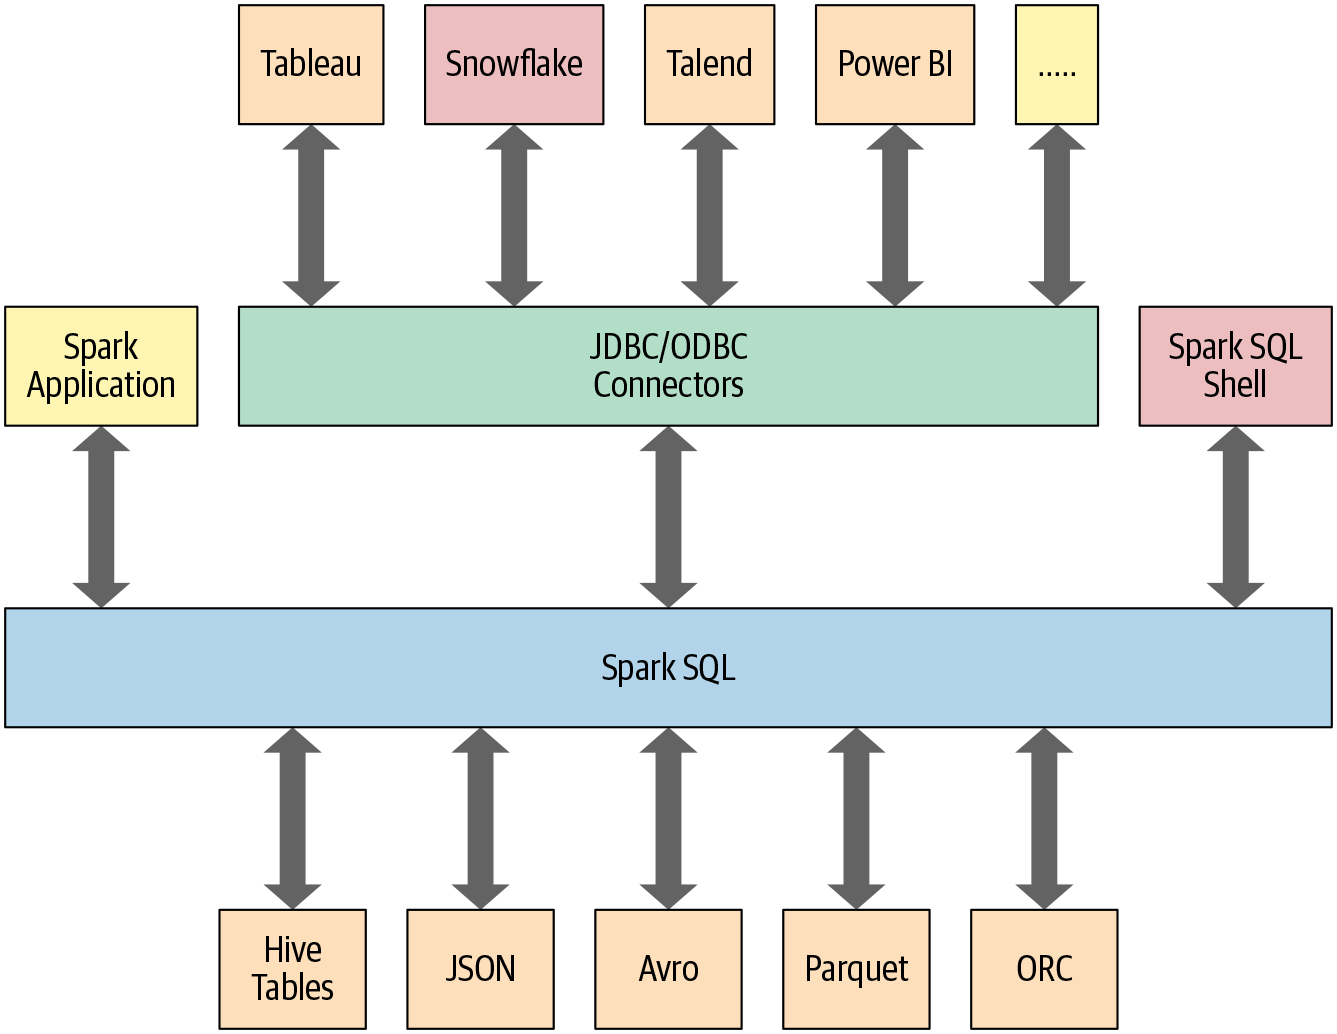

### Understanding Spark SQL Architecture

Spark SQL represents a paradigm shift in big data processing by bridging the gap between traditional SQL databases and distributed computing frameworks. Think of Spark SQL as a translator that converts familiar SQL language into distributed operations that can run across hundreds or thousands of machines simultaneously.

The architecture consists of several key components working together. The Catalyst optimizer acts as the brain of Spark SQL, analyzing your queries and determining the most efficient execution plan.The optimizer considers data distribution, available resources, and query complexity to create an optimal execution strategy.

Adaptive Query Execution
Adaptive Query Execution (AQE) is an optimization technique in Spark SQL that makes use of the runtime statistics to choose the most efficient query execution plan, which is enabled by default since Apache Spark 3.2.0. Spark SQL can turn on and off AQE by spark.sql.adaptive.enabled as an umbrella configuration.

> When true, enable adaptive query execution, which re-optimizes the query plan in the middle of query execution, based on accurate runtime statistics.

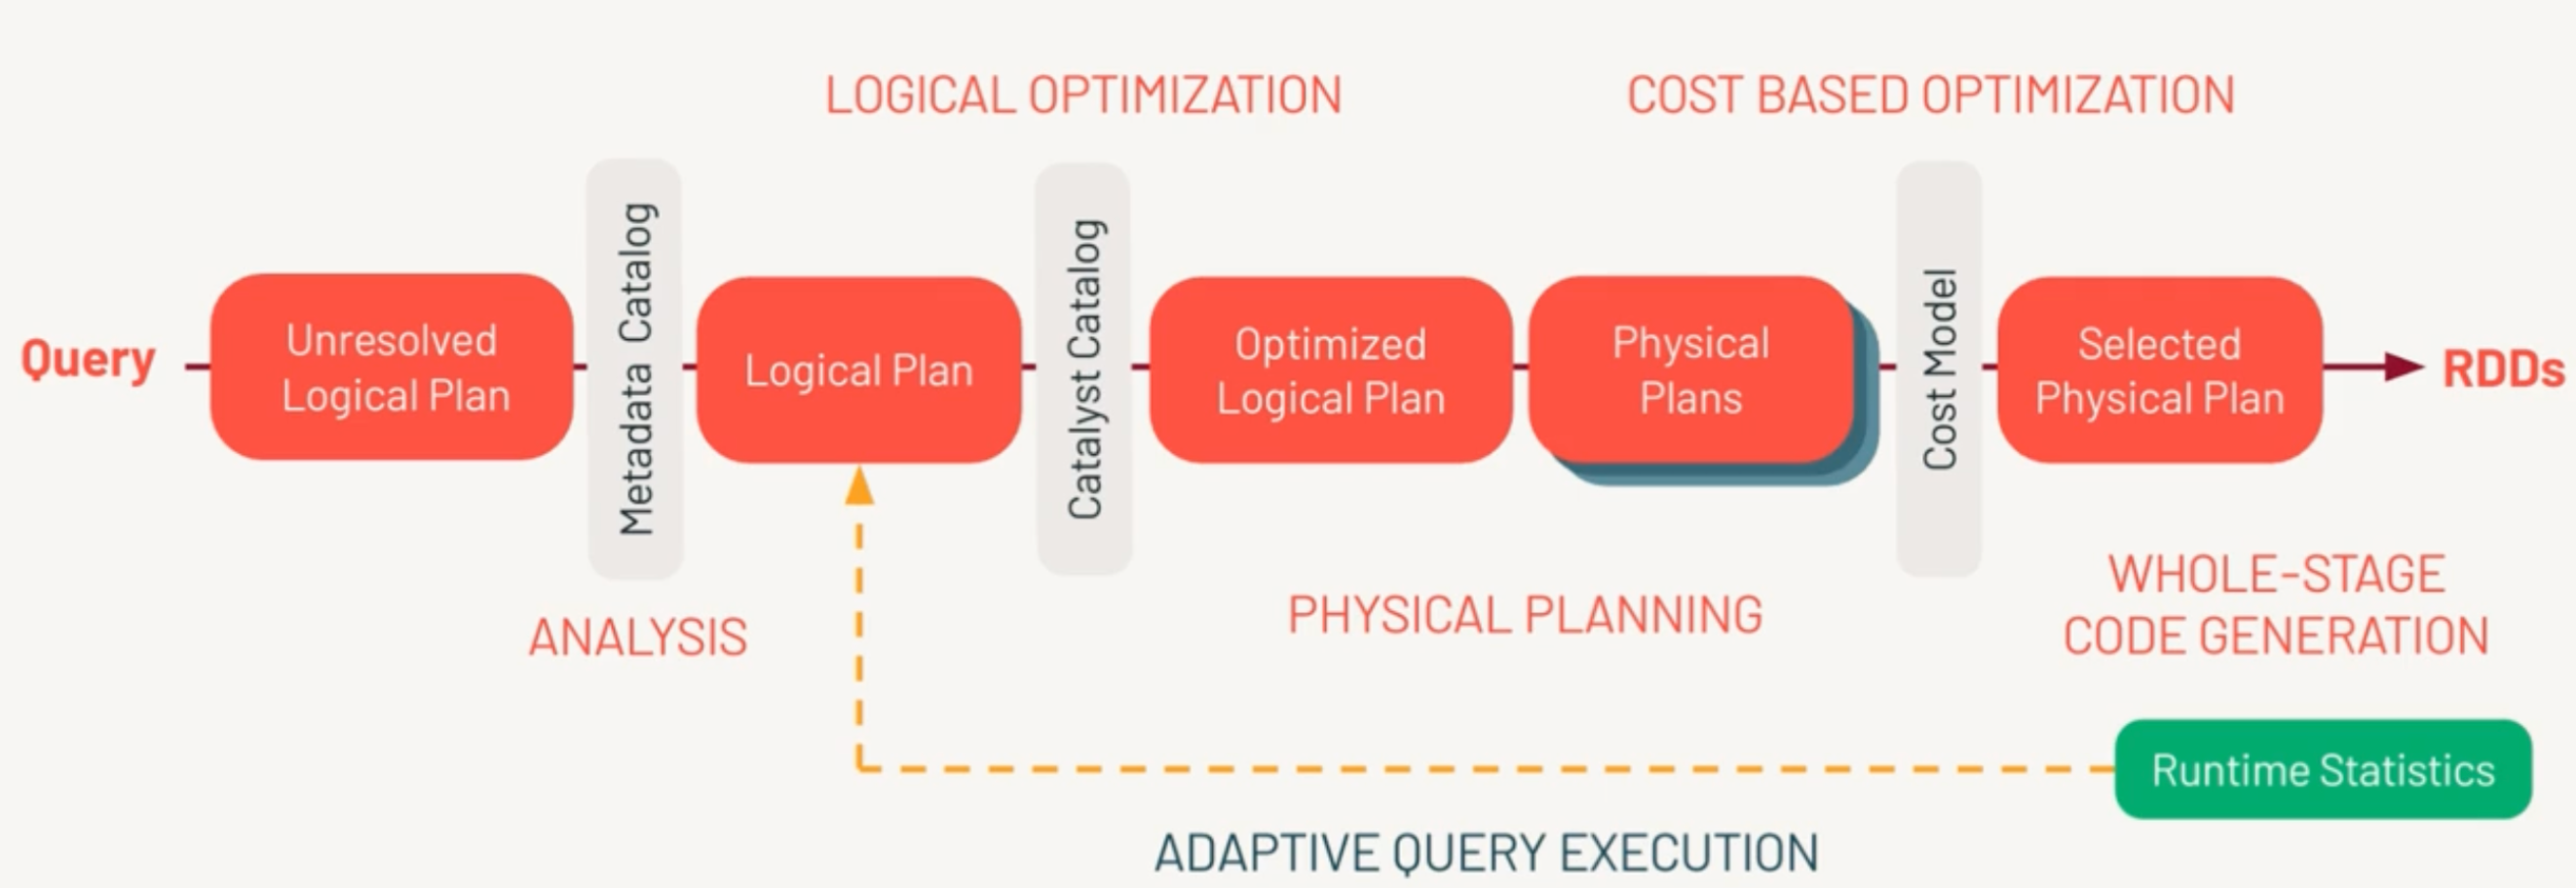

1. When user submits the code to the driver, it implicitly converts the code containing transformations (filters, joins, groupby, unions, etc.) and actions (collect, writes, etc.) into an unresolved logical plan.
2. Driver looks at the plan catalog and confirms that the code has required parameters (for example if the column names are correct for the SQL query or not)and then it is  transformed into a **logical plan**.
   >`Logical plan is created for each job.`
3. And then the Optimizations are applied, once done, the logical plan is converted to many Physical Execution Plans, all these plans are analyzed by the Cost Model. The plan with the minimum cost is selected which contains many jobs and stages.
   

In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

# Create SparkSession with optimized configuration
spark = SparkSession.builder \
    .appName("Disney Plus Data Analysis") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

# Set log level to reduce noise during development
spark.sparkContext.setLogLevel("WARN")

print("Spark Version:", spark.version)
print("Configuration applied successfully")

Spark Version: 3.5.1
Configuration applied successfully


In [2]:
test1 = spark.sql(
    """
    SELECT * FROM csv.`/content/disney_plus_shows.csv`
    LIMIT 5
    """
  )
test1.show()

+---------+--------------------+--------------------+------+-----+-----+-----------+-----------------+-------+--------------------+--------------------+--------------------+--------------------+----------------+---------------+--------------------+---------+-----------+----------+
|      _c0|                 _c1|                 _c2|   _c3|  _c4|  _c5|        _c6|              _c7|    _c8|                 _c9|                _c10|                _c11|                _c12|            _c13|           _c14|                _c15|     _c16|       _c17|      _c18|
+---------+--------------------+--------------------+------+-----+-----+-----------+-----------------+-------+--------------------+--------------------+--------------------+--------------------+----------------+---------------+--------------------+---------+-----------+----------+
|  imdb_id|               title|                plot|  type|rated| year|released_at|         added_at|runtime|               genre|            director|  

#### 3. **Loading Data with Spark SQL**

You can load data into Spark SQL DataFrames from various sources. For this example, we'll use the `disney_plus_shows.csv` dataset.

- **Example: Loading CSV Data**

In [3]:
disney_df = spark.read \
  .format("csv") \
  .option("header", "true") \
  .option("inferSchema", "true") \
  .option("multiline", "true") \
  .option("quote", "\"") \
  .option("escape", "\"") \
  .load("disney_plus_shows.csv")

# Show schema and first few rows
disney_df.printSchema()
disney_df.show(truncate=False)

root
 |-- imdb_id: string (nullable = true)
 |-- title: string (nullable = true)
 |-- plot: string (nullable = true)
 |-- type: string (nullable = true)
 |-- rated: string (nullable = true)
 |-- year: string (nullable = true)
 |-- released_at: string (nullable = true)
 |-- added_at: string (nullable = true)
 |-- runtime: string (nullable = true)
 |-- genre: string (nullable = true)
 |-- director: string (nullable = true)
 |-- writer: string (nullable = true)
 |-- actors: string (nullable = true)
 |-- language: string (nullable = true)
 |-- country: string (nullable = true)
 |-- awards: string (nullable = true)
 |-- metascore: string (nullable = true)
 |-- imdb_rating: string (nullable = true)
 |-- imdb_votes: string (nullable = true)

+----------+------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+-

#### 4. **Registering DataFrames as SQL Tables**

Once the DataFrame is loaded, you can register it as a temporary SQL table to run SQL queries.

- **Example: Registering a DataFrame**

In [4]:
  # Register DataFrame as a SQL table
disney_df.createOrReplaceTempView("disney_shows")

In [32]:
spark.table("disney_shows").printSchema()

root
 |-- imdb_id: string (nullable = true)
 |-- title: string (nullable = true)
 |-- plot: string (nullable = true)
 |-- type: string (nullable = true)
 |-- rated: string (nullable = true)
 |-- year: string (nullable = true)
 |-- released_at: string (nullable = true)
 |-- added_at: string (nullable = true)
 |-- runtime: string (nullable = true)
 |-- genre: string (nullable = true)
 |-- director: string (nullable = true)
 |-- writer: string (nullable = true)
 |-- actors: string (nullable = true)
 |-- language: string (nullable = true)
 |-- country: string (nullable = true)
 |-- awards: string (nullable = true)
 |-- metascore: string (nullable = true)
 |-- imdb_rating: string (nullable = true)
 |-- imdb_votes: string (nullable = true)



In [33]:
spark.sql("DESCRIBE disney_shows").show()

+-----------+---------+-------+
|   col_name|data_type|comment|
+-----------+---------+-------+
|    imdb_id|   string|   NULL|
|      title|   string|   NULL|
|       plot|   string|   NULL|
|       type|   string|   NULL|
|      rated|   string|   NULL|
|       year|   string|   NULL|
|released_at|   string|   NULL|
|   added_at|   string|   NULL|
|    runtime|   string|   NULL|
|      genre|   string|   NULL|
|   director|   string|   NULL|
|     writer|   string|   NULL|
|     actors|   string|   NULL|
|   language|   string|   NULL|
|    country|   string|   NULL|
|     awards|   string|   NULL|
|  metascore|   string|   NULL|
|imdb_rating|   string|   NULL|
| imdb_votes|   string|   NULL|
+-----------+---------+-------+



In [34]:
spark.sql("DESCRIBE EXTENDED disney_shows").show(truncate=False)

+-----------+---------+-------+
|col_name   |data_type|comment|
+-----------+---------+-------+
|imdb_id    |string   |NULL   |
|title      |string   |NULL   |
|plot       |string   |NULL   |
|type       |string   |NULL   |
|rated      |string   |NULL   |
|year       |string   |NULL   |
|released_at|string   |NULL   |
|added_at   |string   |NULL   |
|runtime    |string   |NULL   |
|genre      |string   |NULL   |
|director   |string   |NULL   |
|writer     |string   |NULL   |
|actors     |string   |NULL   |
|language   |string   |NULL   |
|country    |string   |NULL   |
|awards     |string   |NULL   |
|metascore  |string   |NULL   |
|imdb_rating|string   |NULL   |
|imdb_votes |string   |NULL   |
+-----------+---------+-------+



In [35]:
columns_info = spark.catalog.listColumns("disney_shows")
for col in columns_info:
    print(f"Column: {col.name}, Type: {col.dataType}, Nullable: {col.nullable}")

Column: imdb_id, Type: string, Nullable: True
Column: title, Type: string, Nullable: True
Column: plot, Type: string, Nullable: True
Column: type, Type: string, Nullable: True
Column: rated, Type: string, Nullable: True
Column: year, Type: string, Nullable: True
Column: released_at, Type: string, Nullable: True
Column: added_at, Type: string, Nullable: True
Column: runtime, Type: string, Nullable: True
Column: genre, Type: string, Nullable: True
Column: director, Type: string, Nullable: True
Column: writer, Type: string, Nullable: True
Column: actors, Type: string, Nullable: True
Column: language, Type: string, Nullable: True
Column: country, Type: string, Nullable: True
Column: awards, Type: string, Nullable: True
Column: metascore, Type: string, Nullable: True
Column: imdb_rating, Type: string, Nullable: True
Column: imdb_votes, Type: string, Nullable: True


---


#### 5. **Basic SQL Queries**

With the DataFrame registered as a SQL table, you can now run SQL queries on it.

- **Example: Basic SQL Query**

In [5]:
result = spark.sql("""
  SELECT title, genre, imdb_rating
  FROM disney_shows
  WHERE imdb_rating > 7.0
""")

result.show(truncate=False)

+------------------------------------+---------------------------------------------------------------+-----------+
|title                               |genre                                                          |imdb_rating|
+------------------------------------+---------------------------------------------------------------+-----------+
|10 Things I Hate About You          |Comedy, Drama, Romance                                         |7.3        |
|20,000 Leagues Under the Sea        |Adventure, Drama, Family, Fantasy, Sci-Fi                      |7.2        |
|A Bug's Life                        |Animation, Adventure, Comedy, Family                           |7.2        |
|A Celebration of the Music from Coco|Music                                                          |7.6        |
|A Tale of Two Critters              |Adventure, Family                                              |7.1        |
|Aladdin                             |Animation, Adventure, Comedy, Family, Fant

#### 6. **Aggregation and Grouping**

Spark SQL supports standard SQL operations such as aggregation and grouping.

- **Example: Aggregating Data**

In [6]:

# This query counts the number of shows in each genre and orders the results by count in descending order.
genre_counts = spark.sql("""
SELECT genre, COUNT(*) as count
FROM disney_shows
GROUP BY genre
ORDER BY count DESC
""")

genre_counts.show(truncate=False)

+---------------------------------------------+-----+
|genre                                        |count|
+---------------------------------------------+-----+
|NULL                                         |98   |
|Documentary                                  |53   |
|Comedy, Family                               |27   |
|Comedy, Drama, Family                        |19   |
|Animation, Short, Comedy, Family             |17   |
|Animation, Adventure, Comedy, Family, Fantasy|17   |
|Action, Adventure, Sci-Fi                    |17   |
|Comedy, Family, Fantasy                      |16   |
|Animation, Adventure, Comedy, Family         |14   |
|Adventure, Family                            |12   |
|Comedy, Family, Sci-Fi                       |12   |
|Animation, Comedy, Family                    |12   |
|Animation, Short, Comedy                     |11   |
|Reality-TV                                   |9    |
|Documentary, Family                          |9    |
|N/A                        

#### 7. **Handling Missing Data**

You can handle missing data in SQL queries using functions like `COALESCE` and `IS NULL`.

- **Example: Handling Null Values**

In [8]:
# Replace null values with a default value
cleaned_data = spark.sql("""
SELECT
title,
COALESCE(genre, 'Unknown') AS genre,
COALESCE(imdb_rating, 0) AS imdb_rating
FROM disney_shows
""")

cleaned_data.show(truncate=False)

+------------------------------------------+---------------------------------------------------------------+-----------+
|title                                     |genre                                                          |imdb_rating|
+------------------------------------------+---------------------------------------------------------------+-----------+
|10 Things I Hate About You                |Comedy, Drama, Romance                                         |7.3        |
|101 Dalmatian Street                      |Animation, Comedy, Family                                      |6.2        |
|101 Dalmatians                            |Adventure, Comedy, Crime, Family                               |5.7        |
|101 Dalmatians 2: Patch's London Adventure|Animation, Adventure, Comedy, Family, Musical                  |5.8        |
|102 Dalmatians                            |Adventure, Comedy, Family                                      |4.9        |
|12 Dates of Christmas          

#### 8. **Joining DataFrames**

You can join multiple DataFrames using SQL.

- **Example: Self-Join**

In [9]:
# Self-join to find shows with the same genre
genre_joins = spark.sql("""
SELECT a.title AS show1, b.title AS show2, a.genre
FROM disney_shows a
JOIN disney_shows b
ON a.genre = b.genre
WHERE a.title <> b.title
""")

genre_joins.show(truncate=False)

+------------------------------------------+--------------------------------------------------------+---------------------------------------------+
|show1                                     |show2                                                   |genre                                        |
+------------------------------------------+--------------------------------------------------------+---------------------------------------------+
|10 Things I Hate About You                |Stargirl                                                |Comedy, Drama, Romance                       |
|101 Dalmatian Street                      |The Reluctant Dragon                                    |Animation, Comedy, Family                    |
|101 Dalmatian Street                      |Recess: Taking the Fifth Grade                          |Animation, Comedy, Family                    |
|101 Dalmatian Street                      |Recess: School's Out                                    |Animation, 

#### 9. **Subqueries and Nested Queries**

Spark SQL supports subqueries and nested queries, allowing for complex data retrieval.

- **Example: Subquery**

In [36]:
# Find the shows with the highest IMDb rating in each genre
top_rated_shows = spark.sql("""
SELECT title, genre, imdb_rating,
       CAST(imdb_rating AS DOUBLE) AS numeric_rating
FROM disney_shows d1
WHERE CAST(imdb_rating AS DOUBLE) = (
    SELECT MAX(CAST(imdb_rating AS DOUBLE))
    FROM disney_shows d2
    WHERE d2.genre = d1.genre
)
ORDER BY CAST(imdb_rating AS DOUBLE) DESC
""")
top_rated_shows.show(truncate=False)


+----------------------------------------------+----------------------------------------------------------------------+-----------+--------------+
|title                                         |genre                                                                 |imdb_rating|numeric_rating|
+----------------------------------------------+----------------------------------------------------------------------+-----------+--------------+
|Bluey                                         |Animation                                                             |9.7        |9.7           |
|The Imagineering Story                        |Documentary                                                           |9.1        |9.1           |
|Gravity Falls                                 |Animation, Action, Adventure, Comedy, Family, Fantasy, Mystery, Sci-Fi|8.9        |8.9           |
|Dr. T, Lone Star Vet                          |Reality-TV                                                            

#### 10. **Working with Dates and Times**

Spark SQL provides functions to handle date and time operations.

- 10.1 **Example: Extract Year from Date**

In [30]:
# Extract year from the released_at column
shows_with_year = spark.sql("""
SELECT title, released_at,
YEAR(To_DATE(released_at, 'dd MMM yyyy')) AS release_year
FROM disney_shows
""")

shows_with_year.show(5, truncate=False)

+------------------------------------------+-----------+------------+
|title                                     |released_at|release_year|
+------------------------------------------+-----------+------------+
|10 Things I Hate About You                |31 Mar 1999|1999        |
|101 Dalmatian Street                      |25 Mar 2019|2019        |
|101 Dalmatians                            |27 Nov 1996|1996        |
|101 Dalmatians 2: Patch's London Adventure|21 Jan 2003|2003        |
|102 Dalmatians                            |22 Nov 2000|2000        |
+------------------------------------------+-----------+------------+
only showing top 5 rows



In [13]:
# First cast the released_at to date format, then extract year
shows_with_year = spark.sql("""
SELECT title,
       released_at,
       TO_DATE(released_at, 'dd MMM yyyy') AS released_date,
       YEAR(TO_DATE(released_at, 'dd MMM yyyy')) AS release_year
FROM disney_shows
""")
shows_with_year.show(5,truncate=False)

+------------------------------------------+-----------+-------------+------------+
|title                                     |released_at|released_date|release_year|
+------------------------------------------+-----------+-------------+------------+
|10 Things I Hate About You                |31 Mar 1999|1999-03-31   |1999        |
|101 Dalmatian Street                      |25 Mar 2019|2019-03-25   |2019        |
|101 Dalmatians                            |27 Nov 1996|1996-11-27   |1996        |
|101 Dalmatians 2: Patch's London Adventure|21 Jan 2003|2003-01-21   |2003        |
|102 Dalmatians                            |22 Nov 2000|2000-11-22   |2000        |
+------------------------------------------+-----------+-------------+------------+
only showing top 5 rows



- 10.2 **Example: Filtering by Date Range**

In [21]:
# Filter shows released after January 1, 2020
recent_shows = spark.sql("""
SELECT title, released_at
FROM disney_shows
WHERE To_DATE(released_at, 'dd MMM yyyy') >= '2020-03-15'
""")

recent_shows.show(truncate=False)

+------------------------------------+-----------+
|title                               |released_at|
+------------------------------------+-----------+
|A Celebration of the Music from Coco|10 Apr 2020|
|Be Our Chef                         |27 Mar 2020|
|Insider                             |20 Mar 2020|
|Diving with Dolphins                |03 Apr 2020|
|Dolphin Reef                        |03 Apr 2020|
|Elephant                            |03 Apr 2020|
|In the Footsteps of Elephant        |03 Apr 2020|
|Penguins: Life on the Edge          |03 Apr 2020|
+------------------------------------+-----------+



#### 11. **Advanced SQL Functions**

Spark SQL includes advanced functions for data manipulation.

- 11.1 **Example: String Functions**

In [25]:
# Extract the first 25 characters of the plot
short_plots = spark.sql("""
SELECT title, SUBSTRING(plot, 1, 25) AS short_plot
FROM disney_shows
""")

short_plots.show(5, truncate=False)

+------------------------------------------+-------------------------+
|title                                     |short_plot               |
+------------------------------------------+-------------------------+
|10 Things I Hate About You                |A pretty, popular teenage|
|101 Dalmatian Street                      |This series follows the l|
|101 Dalmatians                            |An evil high-fashion desi|
|101 Dalmatians 2: Patch's London Adventure|Being one of 101 takes it|
|102 Dalmatians                            |Cruella DeVil gets out of|
+------------------------------------------+-------------------------+
only showing top 5 rows



- 11.2 **Example: Aggregating with Window Functions**

In [27]:
disney_df.columns

['imdb_id',
 'title',
 'plot',
 'type',
 'rated',
 'year',
 'released_at',
 'added_at',
 'runtime',
 'genre',
 'director',
 'writer',
 'actors',
 'language',
 'country',
 'awards',
 'metascore',
 'imdb_rating',
 'imdb_votes']

In [29]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col

# Use window function to rank shows within each genre by IMDb rating
window_spec = Window.partitionBy("genre").orderBy(col("imdb_rating").desc())

ranked_shows = disney_df.withColumn("rank", row_number().over(window_spec))
ranked_shows.createOrReplaceTempView("ranked_shows")

top_ranked = spark.sql("""
SELECT title, genre, imdb_rating, rank
FROM ranked_shows
WHERE rank = 1
""")

top_ranked.show(truncate=False)

+----------------------------------+--------------------------------------------------------+-----------+----+
|title                             |genre                                                   |imdb_rating|rank|
+----------------------------------+--------------------------------------------------------+-----------+----+
|NULL                              |NULL                                                    |NULL       |1   |
|Disneyland Around the Seasons     |Action, Adventure, Biography, Drama, Family             |N/A        |1   |
|Kim Possible                      |Action, Adventure, Comedy                               |3.6        |1   |
|Dadnapped                         |Action, Adventure, Comedy, Crime, Family                |4.9        |1   |
|Herbie Goes to Monte Carlo        |Action, Adventure, Comedy, Crime, Family, Romance, Sport|5.7        |1   |
|Inspector Gadget                  |Action, Adventure, Comedy, Crime, Family, Sci-Fi        |4.1        |1   |
|